# 02 — Construcción del dataset gold (tareas 3–9)

- **Tarea 3:** lectura de `gold_features_horaria`, features de calendario, `join` con `historico_calefaccion` → `data/silver/dataset_tarea3_limpio.csv`.
- **Tareas 4–5:** regresión lineal con `StandardScaler` para inferir `temp_calefaccion`.
- **Tarea 6:** regla sobre temperatura inferida → `calefaccion_encendida`.
- **Tareas 7–8:** minutos abiertos ponderados, umbral de derroche, `derroche_siguiente_hora`.
- **Tarea 9:** CSV final `data/gold/dataset_tarea9_final.csv` para la red neuronal.

In [10]:
import pandas as pd
import psycopg2
import numpy as np
import os

conexion = psycopg2.connect(
    host="localhost", port="5432", database="postgres", user="postgres", password="Qwe1234."
)
query = "SELECT * FROM gold_features_horaria ORDER BY fecha_hora_utc ASC;"
df_sql = pd.read_sql_query(query, conexion)
conexion.close()

df_sql['fecha_hora_utc'] = pd.to_datetime(df_sql['fecha_hora_utc']).dt.tz_localize(None)
df_sql.set_index('fecha_hora_utc', inplace=True)

df_sql['hora_del_dia'] = df_sql.index.hour
df_sql['dia_de_la_semana'] = df_sql.index.isocalendar().day
df_sql['mes_del_ano'] = df_sql.index.month

df_sql = df_sql.ffill().bfill()

df_csv = pd.read_csv(
    '../data/bronze/historico_calefaccion.csv', 
    header=0,
    names=['fecha', 'hora_str', 'temp_calefaccion', 'hum_calefaccion']
)

df_csv['fecha_hora_str'] = df_csv['fecha'].astype(str) + ' ' + df_csv['hora_str'].astype(str)
df_csv['hora_index'] = pd.to_datetime(df_csv['fecha_hora_str'], format='%Y.%m.%d %H:%M')
df_csv.set_index('hora_index', inplace=True)

df_csv = df_csv[['temp_calefaccion']]
df_csv['temp_calefaccion'] = pd.to_numeric(df_csv['temp_calefaccion'], errors='coerce')

df_tarea3 = df_sql.join(df_csv, how='inner')

os.makedirs('../data/silver', exist_ok=True)
df_tarea3.to_csv('../data/silver/dataset_tarea3_limpio.csv')

/tmp/ipykernel_1422209/861855165.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sql = pd.read_sql_query(query, conexion)


In [11]:
df_tarea3.head()

,temp_aula,hum_aula,pres_aula,min_puerta_1,min_ventana_1,min_ventana_2,min_ventana_3,min_ventana_4,min_ventana_5,min_ventana_6,...,temp_exterior,nubosidad,hum_exterior,vel_viento,elevacion_sol,acimut_sol,hora_del_dia,dia_de_la_semana,mes_del_ano,temp_calefaccion
2025-09-17 11:00:00,30.260000,50.670000,1009.20,0.0,40.0,0.0,0.0,0.0,0.0,0.0,...,29.5,0.0,52.0,11.9,52.500000,176.530000,11,3,9,27.9
2025-09-17 12:00:00,28.956667,47.276667,1009.20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,29.7,1.6,51.0,14.0,51.664667,192.975333,12,3,9,28.4
2025-09-17 13:00:00,26.130000,43.818571,1016.40,24.0,0.0,0.0,0.0,0.0,0.0,0.0,...,29.4,0.0,57.0,15.1,46.929333,214.914667,13,3,9,28.6
2025-09-17 14:00:00,25.870000,45.895000,1016.00,24.0,0.0,0.0,0.0,0.0,0.0,0.0,...,29.0,0.0,59.0,16.6,38.919333,232.378000,14,3,9,28.0
2025-09-17 15:00:00,25.817500,48.275000,1015.92,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,28.3,0.0,62.0,17.3,28.991333,245.992000,15,3,9,28.7


Tarea 4

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

_EXTRA_COLS = [
    'hora_sin', 'hora_cos', 'dow_sin', 'dow_cos', 'mes_sin', 'mes_cos',
    'temp_aula_minus_exterior', 'temp_calefaccion_lag1', 'temp_aula_roll3',
    'temp_aula_roll24', 'temp_calefaccion_inferida',
]

df = pd.read_csv('../data/silver/dataset_tarea3_limpio.csv', index_col=0, parse_dates=True)
df = df.sort_index()
for c in _EXTRA_COLS:
    if c in df.columns:
        df = df.drop(columns=[c])

df = df.dropna()

X = df.drop(columns=['temp_calefaccion'])
y = df['temp_calefaccion']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

modelo_calefaccion = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('reg', LinearRegression()),
    ]
)
modelo_calefaccion.fit(X_train, y_train)

y_pred = modelo_calefaccion.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE (Error Absoluto Medio): {mae:.2f} ºC")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f} ºC")
print(f"R2 Score: {r2:.4f}")

MAE (Error Absoluto Medio): 0.51 ºC
RMSE (Raíz del Error Cuadrático Medio): 0.69 ºC
R2 Score: 0.7445


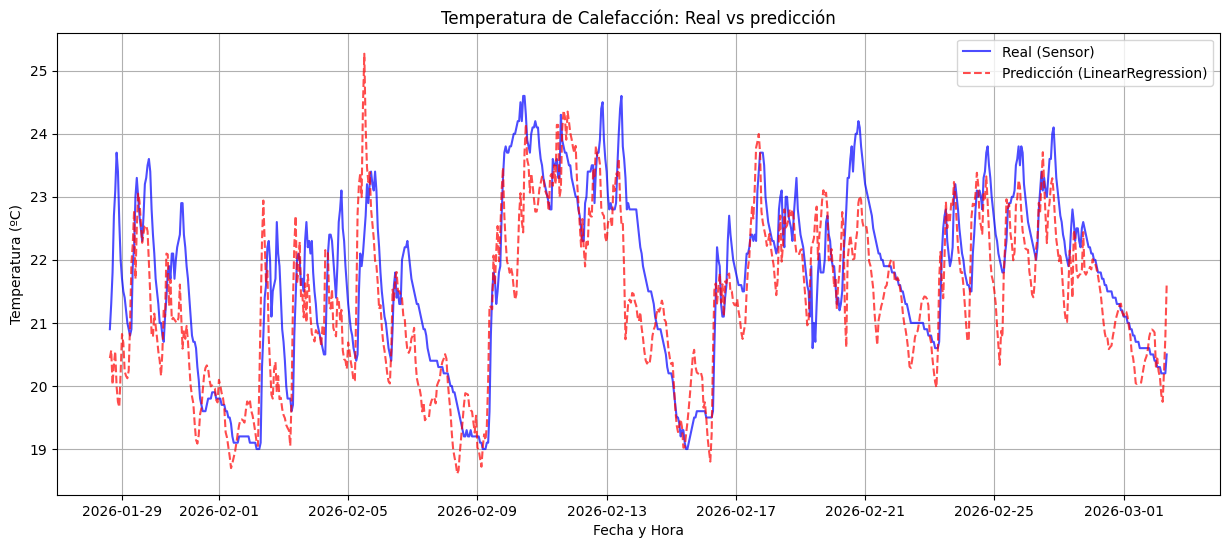

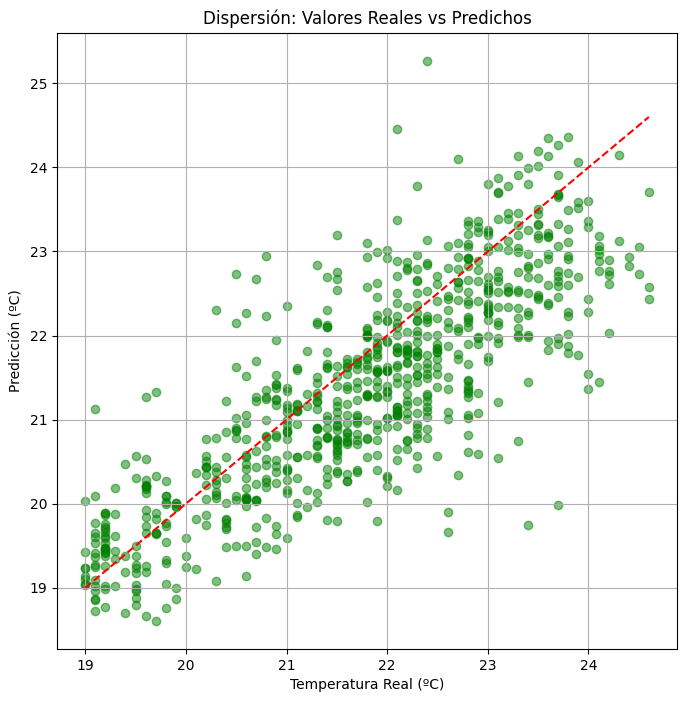

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(y_test.index, y_test.values, label='Real (Sensor)', color='blue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Predicción (LinearRegression)', color='red', alpha=0.7, linestyle='--')
plt.title('Temperatura de Calefacción: Real vs predicción')
plt.xlabel('Fecha y Hora')
plt.ylabel('Temperatura (ºC)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Dispersión: Valores Reales vs Predichos')
plt.xlabel('Temperatura Real (ºC)')
plt.ylabel('Predicción (ºC)')
plt.grid(True)
plt.show()

Tarea 5

In [ ]:
X_todo = df.drop(columns=['temp_calefaccion'])
df['temp_calefaccion_inferida'] = modelo_calefaccion.predict(X_todo)
df.to_csv('../data/silver/dataset_tarea3_limpio.csv')

In [6]:
df.head()

,temp_aula,hum_aula,pres_aula,min_puerta_1,min_ventana_1,min_ventana_2,min_ventana_3,min_ventana_4,min_ventana_5,min_ventana_6,...,nubosidad,hum_exterior,vel_viento,elevacion_sol,acimut_sol,hora_del_dia,dia_de_la_semana,mes_del_ano,temp_calefaccion,temp_calefaccion_inferida
2025-09-17 11:00:00,30.260000,50.670000,1009.20,0.0,40.0,0.0,0.0,0.0,0.0,0.0,...,0.0,52.0,11.9,52.500000,176.530000,11,3,9,27.9,29.531305
2025-09-17 12:00:00,28.956667,47.276667,1009.20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.6,51.0,14.0,51.664667,192.975333,12,3,9,28.4,29.358736
2025-09-17 13:00:00,26.130000,43.818571,1016.40,24.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,57.0,15.1,46.929333,214.914667,13,3,9,28.6,28.004266
2025-09-17 14:00:00,25.870000,45.895000,1016.00,24.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,59.0,16.6,38.919333,232.378000,14,3,9,28.0,27.742536
2025-09-17 15:00:00,25.817500,48.275000,1015.92,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,62.0,17.3,28.991333,245.992000,15,3,9,28.7,27.353925


Tarea 6

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/silver/dataset_tarea3_limpio.csv', index_col=0, parse_dates=True)

def algoritmo_termostato(row):
    dia = row['dia_de_la_semana']
    hora = row['hora_del_dia']
    temp = row['temp_aula']
    
    if dia > 5:
        return 0
        
    if (7 <= hora < 16) or (18 <= hora <= 20):
        if temp < 21.9:
            return 1
        elif temp > 22.0:
            return 0
        else:
            return np.nan 
            
    elif 16 <= hora < 18:
        if temp < 21.5:
            return 1
        elif temp > 21.6:
            return 0
        else:
            return np.nan 
            
    return 0

df['calefaccion_regla'] = df.apply(algoritmo_termostato, axis=1)

df['calefaccion_regla'] = df['calefaccion_regla'].ffill().fillna(0)

df['calefaccion_inferida_sensor'] = np.where(df['temp_calefaccion_inferida'] > 27.0, 1, 0)

df['calefaccion_encendida'] = np.where(
    df['calefaccion_inferida_sensor'] == 1, 
    1, 
    df['calefaccion_regla']
)

df = df.drop(columns=['calefaccion_regla', 'calefaccion_inferida_sensor'])

df.to_csv('../data/gold/dataset_tarea6.csv')

df.tail()

,temp_aula,hum_aula,pres_aula,min_puerta_1,min_ventana_1,min_ventana_2,min_ventana_3,min_ventana_4,min_ventana_5,min_ventana_6,...,hum_exterior,vel_viento,elevacion_sol,acimut_sol,hora_del_dia,dia_de_la_semana,mes_del_ano,temp_calefaccion,temp_calefaccion_inferida,calefaccion_encendida
2026-03-02 04:00:00,17.860000,53.620000,1015.60,0.0,0.0,60.0,30.0,0.0,0.0,60.0,...,94.0,6.1,-23.773333,79.246667,4,1,3,20.2,19.861955,0.0
2026-03-02 05:00:00,17.860000,53.653333,1015.30,0.0,0.0,60.0,30.0,0.0,0.0,60.0,...,93.0,5.8,-12.681250,88.863750,5,1,3,20.2,19.748723,0.0
2026-03-02 06:00:00,18.230000,53.360000,1015.20,30.0,0.0,60.0,30.0,0.0,0.0,60.0,...,90.0,6.8,0.126190,99.229048,6,1,3,20.2,20.225578,0.0
2026-03-02 07:00:00,19.598333,56.124000,1015.55,30.0,0.0,60.0,30.0,0.0,0.0,60.0,...,90.0,7.2,9.091304,107.147826,7,1,3,20.2,20.767371,1.0
2026-03-02 08:00:00,21.260000,59.346667,1015.85,30.0,0.0,60.0,30.0,0.0,30.0,60.0,...,90.0,7.2,18.183750,116.107500,8,1,3,20.5,21.622120,1.0


Tarea 7

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/gold/dataset_tarea6.csv', index_col=0, parse_dates=True)

col_puerta = ['min_puerta_1']
col_ventanas_inf = ['min_ventana_1', 'min_ventana_2', 'min_ventana_3', 'min_ventana_4', 'min_ventana_5', 'min_ventana_6'] 
col_ventanas_sup = ['min_ventana_7', 'min_ventana_8', 'min_ventana_9', 'min_ventana_10', 'min_ventana_11', 'min_ventana_12'] 

min_puerta = df[col_puerta].sum(axis=1) * 2.0
min_inf = df[col_ventanas_inf].sum(axis=1) * 1.0
min_sup = df[col_ventanas_sup].sum(axis=1) * 0.5

df['min_totales_ponderados'] = min_puerta + min_inf + min_sup

porcentaje_derroche = 0.20
umbral_minutos = 60 * porcentaje_derroche

df['derroche_actual'] = np.where(
    (df['calefaccion_encendida'] == 1) & (df['min_totales_ponderados'] > umbral_minutos),
    1,
    0
)

df.to_csv('../data/gold/dataset_tarea7.csv')
df.head()

,temp_aula,hum_aula,pres_aula,min_puerta_1,min_ventana_1,min_ventana_2,min_ventana_3,min_ventana_4,min_ventana_5,min_ventana_6,...,elevacion_sol,acimut_sol,hora_del_dia,dia_de_la_semana,mes_del_ano,temp_calefaccion,temp_calefaccion_inferida,calefaccion_encendida,min_totales_ponderados,derroche_actual
2025-09-17 11:00:00,30.260000,50.670000,1009.20,0.0,40.0,0.0,0.0,0.0,0.0,0.0,...,52.500000,176.530000,11,3,9,27.9,29.531305,1.0,40.0,1
2025-09-17 12:00:00,28.956667,47.276667,1009.20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,51.664667,192.975333,12,3,9,28.4,29.358736,1.0,0.0,0
2025-09-17 13:00:00,26.130000,43.818571,1016.40,24.0,0.0,0.0,0.0,0.0,0.0,0.0,...,46.929333,214.914667,13,3,9,28.6,28.004266,1.0,48.0,1
2025-09-17 14:00:00,25.870000,45.895000,1016.00,24.0,0.0,0.0,0.0,0.0,0.0,0.0,...,38.919333,232.378000,14,3,9,28.0,27.742536,1.0,48.0,1
2025-09-17 15:00:00,25.817500,48.275000,1015.92,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,28.991333,245.992000,15,3,9,28.7,27.353925,1.0,0.0,0


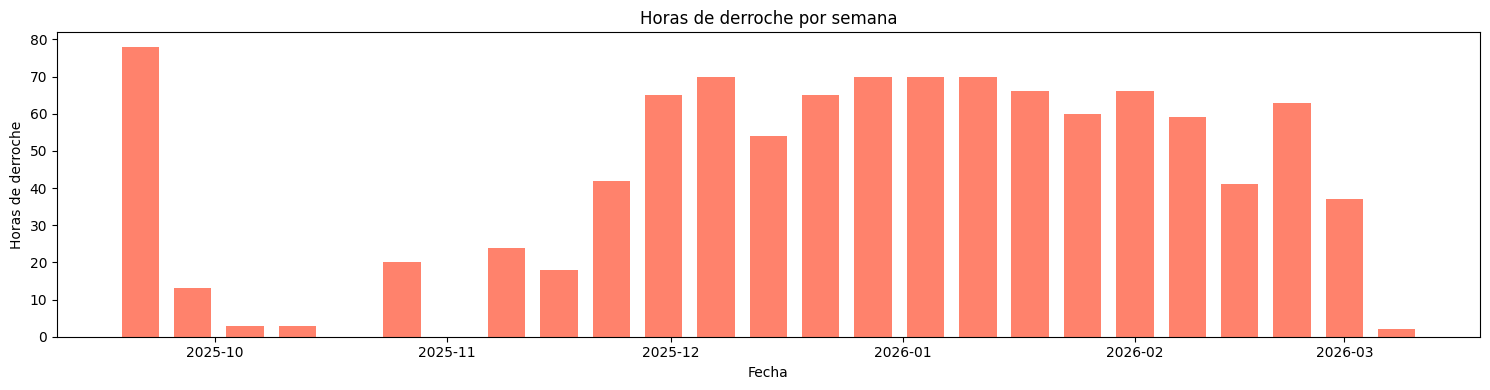

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

df_plot = df.resample('W')['derroche_actual'].sum()
plt.figure(figsize=(15, 4))
plt.bar(df_plot.index, df_plot.values, width=5, color='tomato', alpha=0.8)
plt.title('Horas de derroche por semana')
plt.xlabel('Fecha')
plt.ylabel('Horas de derroche')
plt.tight_layout()
plt.show()

Tarea 8

In [9]:
import pandas as pd

df = pd.read_csv('../data/gold/dataset_tarea7.csv', index_col=0, parse_dates=True)

df['derroche_siguiente_hora'] = df['derroche_actual'].shift(-1)

df = df.dropna(subset=['derroche_siguiente_hora'])
df['derroche_siguiente_hora'] = df['derroche_siguiente_hora'].astype(int)

df.to_csv('../data/gold/dataset_tarea8.csv')
df.head()

,temp_aula,hum_aula,pres_aula,min_puerta_1,min_ventana_1,min_ventana_2,min_ventana_3,min_ventana_4,min_ventana_5,min_ventana_6,...,acimut_sol,hora_del_dia,dia_de_la_semana,mes_del_ano,temp_calefaccion,temp_calefaccion_inferida,calefaccion_encendida,min_totales_ponderados,derroche_actual,derroche_siguiente_hora
2025-09-17 11:00:00,30.260000,50.670000,1009.20,0.0,40.0,0.0,0.0,0.0,0.0,0.0,...,176.530000,11,3,9,27.9,29.531305,1.0,40.0,1,0
2025-09-17 12:00:00,28.956667,47.276667,1009.20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,192.975333,12,3,9,28.4,29.358736,1.0,0.0,0,1
2025-09-17 13:00:00,26.130000,43.818571,1016.40,24.0,0.0,0.0,0.0,0.0,0.0,0.0,...,214.914667,13,3,9,28.6,28.004266,1.0,48.0,1,1
2025-09-17 14:00:00,25.870000,45.895000,1016.00,24.0,0.0,0.0,0.0,0.0,0.0,0.0,...,232.378000,14,3,9,28.0,27.742536,1.0,48.0,1,0
2025-09-17 15:00:00,25.817500,48.275000,1015.92,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,245.992000,15,3,9,28.7,27.353925,1.0,0.0,0,0


In [10]:
df = pd.read_csv('../data/gold/dataset_tarea8.csv', index_col=0, parse_dates=True)

columnas_finales = [
    'hora_del_dia', 
    'dia_de_la_semana', 
    'mes_del_ano',
    'temp_aula', 
    'hum_aula', 
    'pres_aula',
    'temp_exterior', 
    'nubosidad', 
    'hum_exterior', 
    'vel_viento', 
    'elevacion_sol', 
    'acimut_sol',
    'calefaccion_encendida',
    'derroche_siguiente_hora'
]

df_final = df[columnas_finales]

df_final.to_csv('../data/gold/dataset_tarea9_final.csv')

Comprobacion

In [4]:
df = pd.read_csv('../data/gold/dataset_tarea9_final.csv', index_col=0, parse_dates=True)

print("Filas donde hay derroche en la hora siguiente (Target = 1):")
print(df[df['derroche_siguiente_hora'] == 1].head())

print("\n" + "="*50 + "\n")

print("Filas sin derroche (Target = 0):")
print(df[df['derroche_siguiente_hora'] == 0].head())

print("\n" + "="*50 + "\n")

print("Distribución del target (porcentaje):")
distribucion = df['derroche_siguiente_hora'].value_counts(normalize=True) * 100
print(distribucion.round(2).astype(str) + ' %')

Filas donde hay derroche en la hora siguiente (Target = 1):
                     hora_del_dia  dia_de_la_semana  mes_del_ano  temp_aula  \
2025-09-17 12:00:00            12                 3            9  28.956667   
2025-09-17 13:00:00            13                 3            9  26.130000   
2025-09-18 09:00:00             9                 4            9  26.422500   
2025-09-18 10:00:00            10                 4            9  27.015000   
2025-09-18 11:00:00            11                 4            9  27.235000   

                      hum_aula  pres_aula  temp_exterior  nubosidad  \
2025-09-17 12:00:00  47.276667    1009.20           29.7        1.6   
2025-09-17 13:00:00  43.818571    1016.40           29.4        0.0   
2025-09-18 09:00:00  55.382500    1018.55           26.4        0.0   
2025-09-18 10:00:00  52.840000    1018.20           27.8        0.0   
2025-09-18 11:00:00  53.980000    1017.90           28.5        0.0   

                     hum_exterior  vel

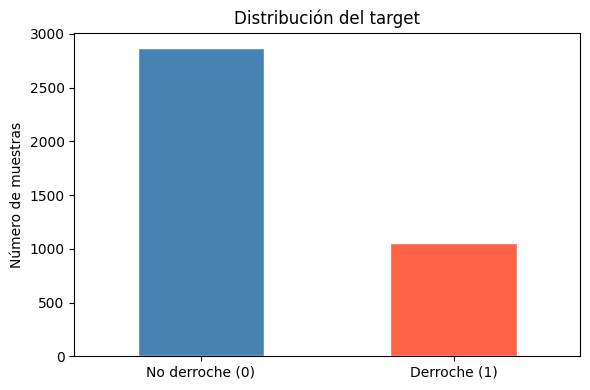

In [5]:
import matplotlib.pyplot as plt

conteo = df['derroche_siguiente_hora'].value_counts().sort_index()
conteo.index = ['No derroche (0)', 'Derroche (1)']
conteo.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white', figsize=(6, 4))
plt.title('Distribución del target')
plt.ylabel('Número de muestras')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
print("Columnas finales:", list(df_final.columns))
print("Shape:", df_final.shape)
print("Target - Derroche sí:", (df_final['derroche_siguiente_hora'] == 1).sum())
print("Target - Derroche no:", (df_final['derroche_siguiente_hora'] == 0).sum())

Columnas finales: ['hora_del_dia', 'dia_de_la_semana', 'mes_del_ano', 'temp_aula', 'hum_aula', 'pres_aula', 'temp_exterior', 'nubosidad', 'hum_exterior', 'vel_viento', 'elevacion_sol', 'acimut_sol', 'calefaccion_encendida', 'derroche_siguiente_hora']
Shape: (3924, 14)
Target - Derroche sí: 1058
Target - Derroche no: 2866
